In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = sns.load_dataset("geyser")

df = df[['duration','waiting','kind']]
df = df.dropna()


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['duration'] = le.fit_transform(df['duration'])
df['waiting'] = le.fit_transform(df['waiting'])
df['kind'] = le.fit_transform(df['kind'])

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["kind"] = le.fit_transform(df["kind"])

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("kind", axis=1)
y = df["kind"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[41  0]
 [ 0 14]]


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


In [10]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [11]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 1.0


In [12]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 1.0


In [13]:
from sklearn.metrics import classification_report

y_train_pred = model.predict(X_train)

print("Training")
print(classification_report(y_train, y_train_pred))

print("Test")
print(classification_report(y_test, y_pred))


Training
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       131
           1       1.00      1.00      1.00        86

    accuracy                           1.00       217
   macro avg       1.00      1.00      1.00       217
weighted avg       1.00      1.00      1.00       217

Test
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        14

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



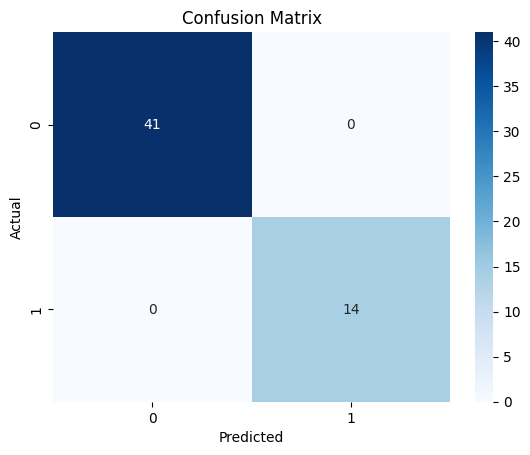

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


In [18]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5)